## Georgia EI Analysis Using PyEI

In [1]:
import pandas as pd
import numpy as np
import json
from pyei.two_by_two import TwoByTwoEI
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import dill

import os
os.environ["PYTENSOR_FLAGS"] = "cxx=,mode=FAST_COMPILE,linker=py"

import shutil
shutil.rmtree(os.path.expanduser("~\\AppData\\Local\\PyTensor"), ignore_errors=True)

c:\Users\leeh1\Rockies-Gerrymandering\repo\rockies\Lib\site-packages\numba\core\decorators.py:248: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
demographics = ['white', 'black', 'latino', 'other']
candidates = ['harris', 'trump']

### Path and DataFrame

In [2]:
path = '../output/Georgia/seawulf.csv'

In [3]:
ga_df = pd.read_csv(path)
ga_df

,UNIQUE_ID,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population,geometry
0,APPLING-:-1B,108,921,2,1031,1074.216587,102.982480,55.003760,3.618320,1235.821146,"POLYGON ((375680.6717 3535246.721, 375706.5104..."
1,APPLING-:-1C,67,724,0,791,1191.912652,472.673691,42.287709,28.713142,1735.587193,"POLYGON ((378693.0887 3524550.847, 378692.8331..."
2,APPLING-:-2,782,541,4,1327,1235.612661,788.224241,96.849558,32.601383,2153.287844,"POLYGON ((380005.7799 3525000.1826, 380113.838..."
3,APPLING-:-3A1,31,617,0,648,705.543283,121.434717,146.434230,7.825296,981.237527,"POLYGON ((377772.2288 3534595.104, 377753.8538..."
4,APPLING-:-3C,246,934,3,1183,1427.934438,416.186299,57.464584,60.117966,1961.703287,"POLYGON ((386430.8865 3520109.3215, 386469.241..."
...,...,...,...,...,...,...,...,...,...,...,...
2715,WORTH-:-SCOOTERVILLE,33,466,0,499,882.262998,21.675616,59.886046,15.588500,979.413160,"POLYGON ((241750.6763 3468959.4477, 241748.751..."
2716,WORTH-:-SUMNER,115,549,2,666,1053.312665,264.181783,2.612231,59.035993,1379.142672,"POLYGON ((248495.8814 3494258.3435, 248494.668..."
2717,WORTH-:-SYLVESTER,1124,738,4,1866,1166.052147,1077.443185,20.669560,38.311600,2302.476493,"POLYGON ((216948.6246 3494724.9875, 216948.695..."
2718,WORTH-:-SYLVESTER EAST,211,1019,3,1233,1586.468847,147.357490,90.820364,159.706155,1984.352857,"POLYGON ((235331.0428 3502013.0719, 235645.208..."


### Isolate Columns Needed + Create Columns Necessary

[Source](https://github.com/mggg/ecological-inference/blob/main/pyei/intro_notebooks/PyEI_overview.ipynb?short_path=f3688a3)

Whether you are using an example data set or your own data, here is what you will need to pass to the various EI methods:

A vector of length `num_precincts` giving the population of each precincts. Depending on your purposes and data, the appropriate measure of population may be CVAP, VAP, etc. Below we name this `precinct_pops`.

For 2 x 2 EI:

- A vector of length `num_precincts` whose entries are each numbers between zero and 1 that give the fraction of the population of each precinct who belong to the demographic group of interest. Below we name this `group_fraction`.
- A vector of length `num_precincts` whose entries are each numbers beteween zero and 1 that give the fraction of voters in each precinct voting for the candidate of interest (or, if we are estimating turnout, who voted at all). Below, we name this `votes_fraction`.
Optionally: name of the candidate of interest, name of the demographic group of interest, and/or names of precincts (for use in PyEI's plotting and reporting).

In [ ]:
ga_df.columns = ga_df.columns.str.lower()

ga_data = ga_df[['unique_id', 'kamala d. harris', 'donald j. trump', 'total_votes', 
                 'white_population', 'black_population', 'latino_population', 'other_population', 'total_population']]
ga_data = ga_data.rename(columns={'unique_id' : 'precincts', 'kamala d. harris' : 'harris', 'donald j. trump' : 'trump'})
ga_data['total'] = ga_data['harris'] + ga_data['trump']

# drop rows with no vote information
ga_data = ga_data[ga_data['total'] > 0]
ga_data

,precincts,harris,trump,total_votes,white_population,black_population,latino_population,other_population,total_population,total
0,APPLING-:-1B,108,921,1031,1074.216587,102.982480,55.003760,3.618320,1235.821146,1029
1,APPLING-:-1C,67,724,791,1191.912652,472.673691,42.287709,28.713142,1735.587193,791
2,APPLING-:-2,782,541,1327,1235.612661,788.224241,96.849558,32.601383,2153.287844,1323
3,APPLING-:-3A1,31,617,648,705.543283,121.434717,146.434230,7.825296,981.237527,648
4,APPLING-:-3C,246,934,1183,1427.934438,416.186299,57.464584,60.117966,1961.703287,1180
...,...,...,...,...,...,...,...,...,...,...
2715,WORTH-:-SCOOTERVILLE,33,466,499,882.262998,21.675616,59.886046,15.588500,979.413160,499
2716,WORTH-:-SUMNER,115,549,666,1053.312665,264.181783,2.612231,59.035993,1379.142672,664
2717,WORTH-:-SYLVESTER,1124,738,1866,1166.052147,1077.443185,20.669560,38.311600,2302.476493,1862
2718,WORTH-:-SYLVESTER EAST,211,1019,1233,1586.468847,147.357490,90.820364,159.706155,1984.352857,1230


In [5]:
def calculate_shares(df):
    result = df[['precincts', 'total']].copy()

    for demographic in demographics:
        result[f'{demographic}_pct'] = (
            df[f'{demographic}_population'] / df['total_population']
        )

    for candidate in candidates:
        result[f'{candidate}_pct'] = (
            df[candidate] / df['total_votes']
        )

    return result

In [6]:
data = calculate_shares(ga_data)
data.head()

,precincts,total,white_pct,black_pct,latino_pct,other_pct,harris_pct,trump_pct
0,APPLING-:-1B,1029,0.869233,0.083331,0.044508,0.002928,0.104753,0.893307
1,APPLING-:-1C,791,0.686749,0.272342,0.024365,0.016544,0.084703,0.915297
2,APPLING-:-2,1323,0.573826,0.366056,0.044978,0.015140,0.589299,0.407687
3,APPLING-:-3A1,648,0.719034,0.123757,0.149234,0.007975,0.047840,0.952160
4,APPLING-:-3C,1180,0.727905,0.212156,0.029293,0.030646,0.207946,0.789518


In [7]:
data.isna().any()

precincts     False
total         False
white_pct     False
black_pct     False
latino_pct    False
other_pct     False
harris_pct    False
trump_pct     False
dtype: bool

## Fitting Model

In [8]:
def fit_king_99(demographic, candidate):
    group_fraction = np.array(data[f"{demographic}_pct"])
    votes_fraction = np.array(data[f"{candidate}_pct"])

    precinct_pops = np.array(data["total"])
    precinct_names = data['precincts']

    ei = TwoByTwoEI(model_name="king99", lmbda=0.5)

    # Fit the model
    ei.fit(group_fraction, 
        votes_fraction, 
        precinct_pops, 
        demographic_group_name=demographic, 
        candidate_name=candidate, 
        precinct_names=precinct_names, 
        draws=1200, # optional
        tune=3000, # optional
        target_accept=.99 # optional
    )

    print(ei.summary())

    return ei


In [9]:
def fit_king_99_modif(demographic, candidate):
    group_fraction = np.array(data[f"{demographic}_pct"])
    votes_fraction = np.array(data[f"{candidate}_pct"])

    precinct_pops = np.array(data["total"])
    precinct_names = data['precincts']

    ei = TwoByTwoEI(model_name="king99_pareto_modification", pareto_scale=15, pareto_shape=2)

    # Fit the model
    ei.fit(group_fraction, 
        votes_fraction, 
        precinct_pops, 
        demographic_group_name=demographic, 
        candidate_name=candidate, 
        precinct_names=precinct_names, 
        draws=1200, # optional
        tune=3000, # optional
        target_accept=.99 # optional
    )

    print(ei.summary())

    return ei


In [12]:
models = {}

for candidate in candidates:
    models[candidate] = {}
    for demographic in demographics:
        ei = fit_king_99_modif(demographic, candidate)
        models[candidate][demographic] = ei

Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:06<?, ?it/s]





Running chain 0:   5%|▌         | 210/4200 [01:05<18:29,  3.60it/s]

Running chain 0:  15%|█▌        | 630/4200 [02:33<13:12,  4.50it/s]


Running chain 0:  20%|██        | 840/4200 [03:24<12:57,  4.32it/s]


Running chain 0:  25%|██▌       | 1050/4200 [04:07<11:39,  4.50it/s]


Running chain 0:  30%|███       | 1260/4200 [04:44<10:06,  4.85it/s]


Running chain 0:  35%|███▌      | 1470/4200 [05:46<10:42,  4.25it/s]


Running chain 0:  40%|████      | 1680/4200 [06:41<10:13,  4.11it/s]


Running chain 0:  45%|████▌     | 1890/4200 [07:21<08:45,  4.40it/s]


Running chain 0:  50%|█████     | 2100/4200 [07:56<07:17,  4.80it/s]


Running chain 0:  55%|█████▌    | 2310/4200 [08:36<06:24,  4.92it/s]


Running chain 0:  60%|██████    | 2520/4200 [09:16<05:34,  5.02it/s]


Running chain 0:  65%|██████▌   | 2730/4200 [09:58<04:52,  5.03it/s]


Running chain 0:  70%|███████

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        white for harris is
        0.215
        The posterior mean for the district-level voting preference of
        non-white for harris is
        0.862
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        white for harris is
        [0.21095785 0.21817577]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-white for harris is
        [0.85679523 0.86675474]
        


Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:03<?, ?it/s]





Running chain 0:  10%|█         | 420/4200 [00:50<06:39,  9.45it/s]


Running chain 0:  15%|█▌        | 630/4200 [01:05<05:16, 11.29it/s]





Running chain 0:  20%|██        | 840/4200 [01:19<04:33, 12.26it/s]


Running chain 0:  20%|██        | 840/4200 [01:35<04:33, 12.26it/s]





Running chain 0:  30%|███       | 1260/4200 [01:53<03:52, 12.62it/s]


Running chain 0:  30%|███       | 1260/4200 [02:05<03:52, 12.62it/s]

Running chain 0:  35%|███▌      | 1470/4200 [02:08<03:32, 12.84it/s]



Running chain 0:  40%|████      | 1680/4200 [02:23<03:07, 13.43it/s]


Running chain 0:  40%|████      | 1680/4200 [02:35<03:07, 13.43it/s]



Running chain 0:  45%|████▌     | 1890/4200 [02:39<02:53, 13.32it/s]


Running chain 0:  50%|█████     | 2100/4200 [02:53<02:33, 13.69it/s]

Running chain 0:  50%|█████     | 2100/4200 [03:05<02:33, 13.69it/s]



Running chain 0:  55%|

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        black for harris is
        0.918
        The posterior mean for the district-level voting preference of
        non-black for harris is
        0.315
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        black for harris is
        [0.91230893 0.92332735]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-black for harris is
        [0.3129983  0.31808099]
        


Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:03<?, ?it/s]





Running chain 0:   5%|▌         | 210/4200 [00:23<06:12, 10.70it/s]


Running chain 0:  10%|█         | 420/4200 [00:32<03:58, 15.86it/s]


Running chain 0:  15%|█▌        | 630/4200 [00:40<03:04, 19.34it/s]


Running chain 0:  20%|██        | 840/4200 [00:47<02:32, 22.03it/s]


Running chain 0:  30%|███       | 1260/4200 [01:03<02:01, 24.16it/s]



Running chain 0:  35%|███▌      | 1470/4200 [01:13<01:59, 22.90it/s]


Running chain 0:  40%|████      | 1680/4200 [01:21<01:43, 24.23it/s]

Running chain 0:  45%|████▌     | 1890/4200 [01:29<01:31, 25.20it/s]



Running chain 0:  50%|█████     | 2100/4200 [01:41<01:36, 21.84it/s]


Running chain 0:  50%|█████     | 2100/4200 [01:51<01:36, 21.84it/s]


Running chain 0:  55%|█████▌    | 2310/4200 [02:02<01:58, 16.00it/s]





Running chain 0:  60%|██████    | 2520/4200 [02:24<02:05, 13.42it/s]




Running chain 0:  65%|█

...

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        black for trump is
        0.076
        The posterior mean for the district-level voting preference of
        non-black for trump is
        0.674
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        black for trump is
        [0.07102963 0.0808057 ]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-black for trump is
        [0.67150006 0.67631539]
        


Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:05<?, ?it/s]


Running chain 0:   5%|▌         | 210/4200 [00:41<11:10,  5.95it/s]


Running chain 0:  10%|█         | 420/4200 [00:56<07:05,  8.89it/s]





Running chain 0:  15%|█▌        | 630/4200 [01:14<05:57, 10.00it/s]

Running chain 0:  20%|██        | 840/4200 [01:28<04:48, 11.66it/s]


Running chain 0:  25%|██▌       | 1050/4200 [01:44<04:20, 12.11it/s]





Running chain 0:  30%|███       | 1260/4200 [01:58<03:49, 12.81it/s]





Running chain 0:  35%|███▌      | 1470/4200 [02:19<03:49, 11.89it/s]




Running chain 0:  40%|████      | 1680/4200 [02:35<03:26, 12.23it/s]




Running chain 0:  45%|████▌     | 1890/4200 [02:53<03:11, 12.05it/s]

Running chain 0:  45%|████▌     | 1890/4200 [03:04<03:11, 12.05it/s]


Running chain 0:  50%|█████     | 2100/4200 [03:17<03:14, 10.79it/s]





Running chain 0:  55%|█████▌    | 2310/4200 [03:42<03:10,  9.93it/s]








Running chai

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        latino for trump is
        0.278
        The posterior mean for the district-level voting preference of
        non-latino for trump is
        0.521
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        latino for trump is
        [0.25083188 0.3111191 ]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-latino for trump is
        [0.51911048 0.52322744]
        


Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:03<?, ?it/s]



Running chain 0:   5%|▌         | 210/4200 [00:26<07:26,  8.94it/s]


Running chain 0:  10%|█         | 420/4200 [00:34<04:20, 14.52it/s]


Running chain 0:  15%|█▌        | 630/4200 [00:43<03:24, 17.46it/s]


Running chain 0:  20%|██        | 840/4200 [00:53<02:54, 19.23it/s]


Running chain 0:  25%|██▌       | 1050/4200 [01:02<02:33, 20.49it/s]



Running chain 0:  30%|███       | 1260/4200 [01:13<02:29, 19.67it/s]


Running chain 0:  35%|███▌      | 1470/4200 [01:26<02:28, 18.35it/s]




Running chain 0:  40%|████      | 1680/4200 [01:38<02:16, 18.42it/s]


Running chain 0:  45%|████▌     | 1890/4200 [01:49<02:06, 18.21it/s]



Running chain 0:  50%|█████     | 2100/4200 [02:02<01:58, 17.79it/s]


Running chain 0:  55%|█████▌    | 2310/4200 [02:15<01:49, 17.29it/s]



Running chain 0:  55%|█████▌    | 2310/4200 [02:27<01:49, 17.29it/s]

Running chain 0:  60%|█████

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        other for trump is
        0.077
        The posterior mean for the district-level voting preference of
        non-other for trump is
        0.534
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        other for trump is
        [0.05431411 0.10664635]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-other for trump is
        [0.53171157 0.53557119]
        


### Saving Models

In [14]:
with open('../output/Georgia/models/ei_models.pkl', 'wb') as f:
    dill.dump(models, f)

### Loading Models

In [3]:
with open('../output/Georgia/models/ei_models.pkl', 'rb') as f:
    models = dill.load(f)

<Axes: title={'center': 'Support for harris'}>

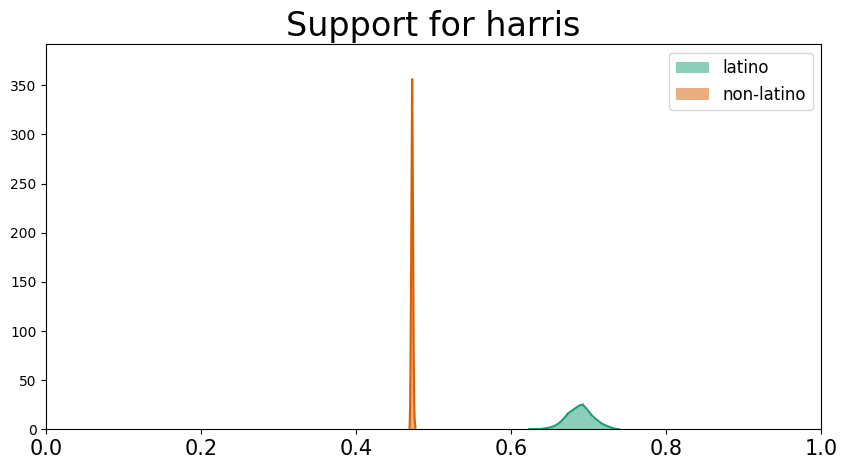

In [4]:
models['harris']['latino'].plot_kde()

In [5]:
print(models['harris']['other'].summary())

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        other for harris is
        0.897
        The posterior mean for the district-level voting preference of
        non-other for harris is
        0.459
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        other for harris is
        [0.86624853 0.92276738]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-other for harris is
        [0.45747357 0.46151097]
        


### Format Fitted Model Data

In [6]:
posterior_means = models['harris']['white'].posterior_mean_voting_prefs
print("white support for harris", posterior_means[0]) # group
print("non-white support for harris ", posterior_means[1]) # complement

white support for harris 0.21456057172110873
non-white support for harris  0.8617686194750953


In [7]:
credible_interval_95 = models['harris']['white'].credible_interval_95_mean_voting_prefs
print("white support for harris", credible_interval_95[0]) # group
print("non-white support for harris ", credible_interval_95[1]) # complement

white support for harris [0.21095785 0.21817577]
non-white support for harris  [0.85679523 0.86675474]


In [8]:
sampled_voting_prefs = models['harris']['white'].sampled_voting_prefs # ei.sampled_voting_prefs is samples of district-level voter preference: list of length 2
#sampled_voting_prefs[0] samples of district-wide support of specified group for specified candidate
#sampled_voting_prefs[1] samples of district-wide support of (complement of specified group) for specified candidate

print("white support for harris", sampled_voting_prefs[0]) # group
print("non-white support for harris ", sampled_voting_prefs[1]) # complement

white support for harris [0.21545162 0.21359506 0.21325713 ... 0.21409716 0.2118609  0.21263345]
non-white support for harris  [0.86191538 0.86161501 0.86692839 ... 0.86399785 0.86652434 0.86168789]


In [9]:

group_samples = sampled_voting_prefs[0]
complement_samples = sampled_voting_prefs[1]

xs = np.linspace(0, 1, 200)
group_density = gaussian_kde(group_samples)(xs)
complement_density = gaussian_kde(complement_samples)(xs)

density_dict = {
    "group": [{"x": float(x), "y": float(y)} for x, y in zip(xs, group_density)],
    "complement": [{"x": float(x), "y": float(y)} for x, y in zip(xs, complement_density)]
}

### Testing Densities

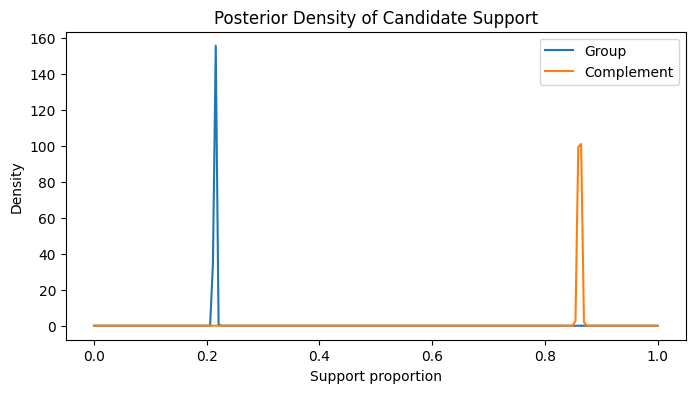

In [10]:
group_xs = [pt['x'] for pt in density_dict['group']]
group_ys = [pt['y'] for pt in density_dict['group']]
comp_xs  = [pt['x'] for pt in density_dict['complement']]
comp_ys  = [pt['y'] for pt in density_dict['complement']]

plt.figure(figsize=(8, 4))
plt.plot(group_xs, group_ys, label="Group")
plt.plot(comp_xs, comp_ys, label="Complement")
plt.xlabel("Support proportion")
plt.ylabel("Density")
plt.title("Posterior Density of Candidate Support")
plt.legend()
plt.show()

In [11]:
def compute_overlap(xs, f1, f2):
    min_density = np.minimum(f1, f2)
    overlap = np.trapezoid(min_density, xs)
    total_f1 = np.trapezoid(f1, xs) 
    return overlap / total_f1

In [12]:
xs = np.linspace(0, 1, 1000)

def group_overlaps_with_white(candidate, group_b, xs):
    white_samples = models[candidate]['white'].sampled_voting_prefs[0]
    group_samples = models[candidate][group_b].sampled_voting_prefs[0]

    f_white = gaussian_kde(white_samples)(xs)
    f_group = gaussian_kde(group_samples)(xs)

    return compute_overlap(xs, f_white, f_group)

for candidate in ['harris', 'trump']:
    print(f"\n{candidate.upper()}")
    for group in ['latino', 'black', 'other']:
        overlap = group_overlaps_with_white(candidate, group, xs)
        print(f"  White vs {group}: {overlap*100:.4f}%")


HARRIS
  White vs latino: 0.0000%
  White vs black: 0.0000%
  White vs other: 0.0000%

TRUMP
  White vs latino: 0.0000%
  White vs black: 0.0000%
  White vs other: 0.0000%


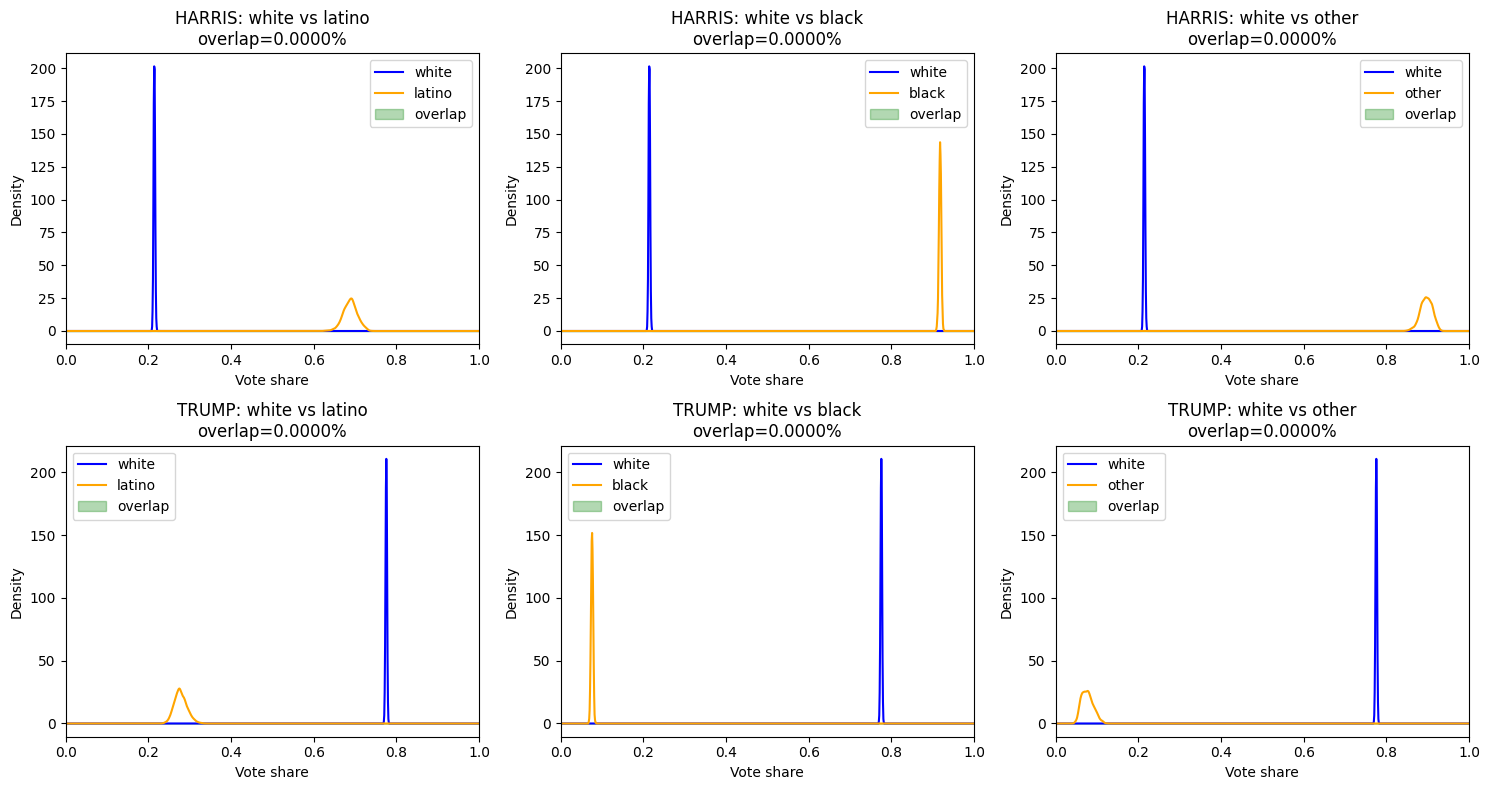

In [13]:
xs = np.linspace(0, 1, 1000)
groups = ['latino', 'black', 'other']
candidates = ['harris', 'trump']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, candidate in enumerate(candidates):
    white_samples = models[candidate]['white'].sampled_voting_prefs[0]
    
    for col, group in enumerate(groups):
        ax = axes[row, col]
        group_samples = models[candidate][group].sampled_voting_prefs[0]

        f_white = gaussian_kde(white_samples)(xs)
        f_group = gaussian_kde(group_samples)(xs)

        ax.plot(xs, f_white, label='white', color='blue')
        ax.plot(xs, f_group, label=group, color='orange')
        ax.fill_between(xs, np.minimum(f_white, f_group), alpha=0.3, color='green', label='overlap')

        overlap = compute_overlap(xs, f_white, f_group)
        ax.set_title(f"{candidate.upper()}: white vs {group}\noverlap={overlap*100:.4f}%")
        ax.set_xlabel("Vote share")
        ax.set_ylabel("Density")
        ax.legend()
        ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

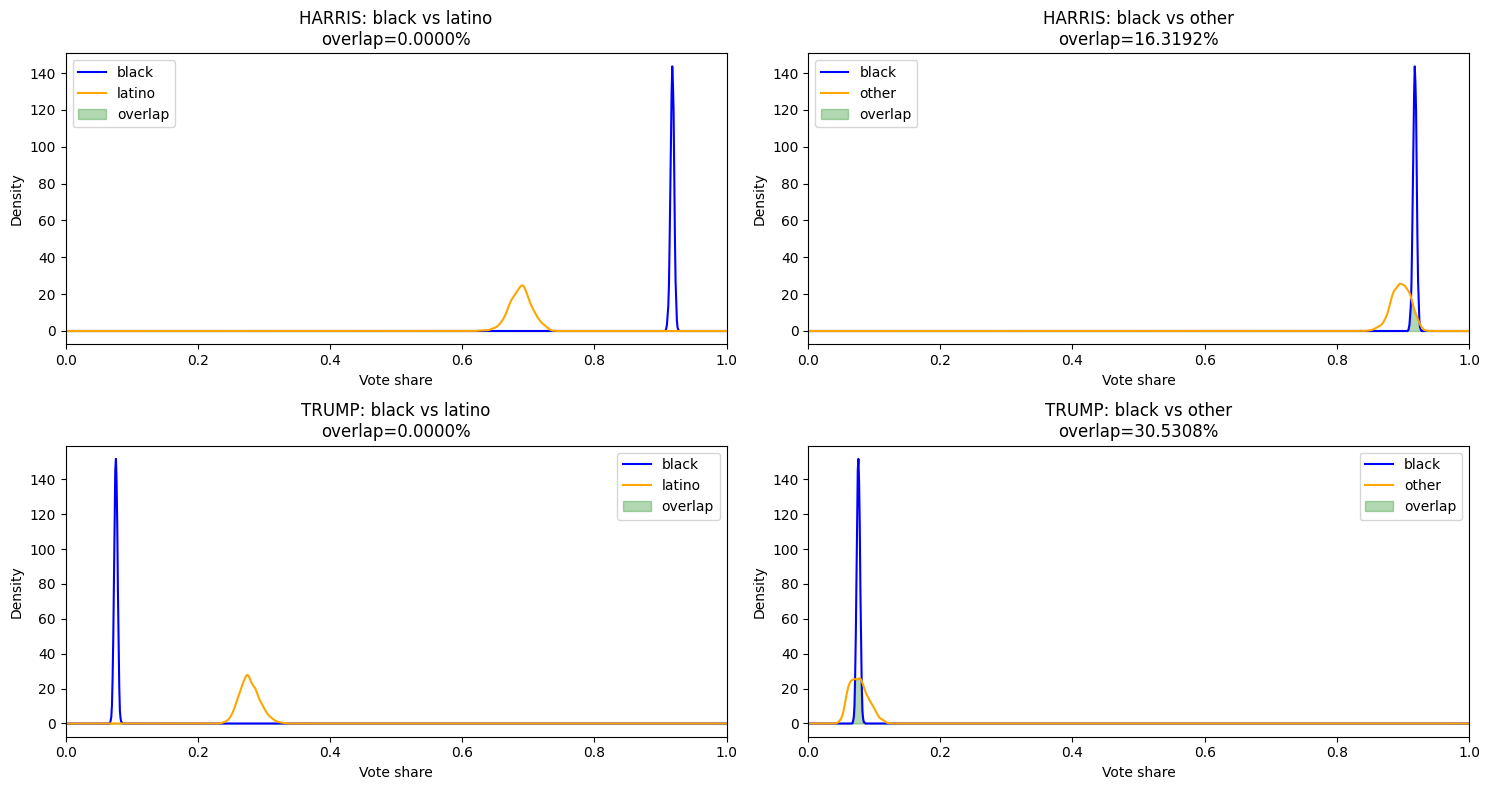

In [14]:
xs = np.linspace(0, 1, 1000)
groups = ['latino', 'other']
candidates = ['harris', 'trump']

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

for row, candidate in enumerate(candidates):
    black_samples = models[candidate]['black'].sampled_voting_prefs[0]
    
    for col, group in enumerate(groups):
        ax = axes[row, col]
        group_samples = models[candidate][group].sampled_voting_prefs[0]

        f_black = gaussian_kde(black_samples)(xs)
        f_group = gaussian_kde(group_samples)(xs)

        ax.plot(xs, f_black, label='black', color='blue')
        ax.plot(xs, f_group, label=group, color='orange')
        ax.fill_between(xs, np.minimum(f_black, f_group), alpha=0.3, color='green', label='overlap')

        overlap = compute_overlap(xs, f_black, f_group)
        ax.set_title(f"{candidate.upper()}: black vs {group}\noverlap={overlap*100:.4f}%")
        ax.set_xlabel("Vote share")
        ax.set_ylabel("Density")
        ax.legend()
        ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### Function to Generate Data

In [15]:
xs = np.linspace(0, 1, 200)
def create_json(models, demographics, candidates):
    ei_json = {"state" : "Georgia", "candidates": []}

    for candidate in candidates:
        cand_entry = {
            "id": candidate.lower(),
            "groups": {}
        }

        white_samples = models[candidate]['white'].sampled_voting_prefs[0]
        f_white = gaussian_kde(white_samples)(xs)

        for demographic in demographics:
            model = models[candidate][demographic]

            # posterior means
            group_mean, complement_mean = model.posterior_mean_voting_prefs
            # posterior_mean = {
            #     "group": group_mean,
            #     "complement": complement_mean
            # }
            posterior_mean = group_mean

            # credible intervals
            group_ci_95, complement_ci_95 = model.credible_interval_95_mean_voting_prefs
            # credible_interval_95 = {
            #     "group": group_ci_95.tolist(),
            #     "complement": complement_ci_95.tolist()
            # }
            credible_interval_95 = group_ci_95.tolist()

            # densities
            sampled_voting_prefs = model.sampled_voting_prefs            
            group_samples = sampled_voting_prefs[0]
            # complement_samples = sampled_voting_prefs[1]

            group_density = gaussian_kde(group_samples)(xs)
            # complement_density = gaussian_kde(complement_samples)(xs)

            overlap = {}
            for other_group in demographics:
                other_samples = models[candidate][other_group].sampled_voting_prefs[0]
                f_other_group = gaussian_kde(other_samples)(xs)
                overlap[other_group] = compute_overlap(xs, f_other_group, group_density)

            # density = {
            #     "group": [{"x": float(x), "y": float(y)} for x, y in zip(xs, group_density)],
            #     "complement": [{"x": float(x), "y": float(y)} for x, y in zip(xs, complement_density)]
            # }

            density = [{"x": float(x), "y": float(y)} for x, y in zip(xs, group_density)]

            cand_entry["groups"][demographic] = {
                "posterior_mean": posterior_mean,
                "credible_interval_95": credible_interval_95,
                "density": density,
                "overlap": overlap,
            }

        ei_json["candidates"].append(cand_entry)
    
    output_path = "../output/Georgia/ga_ei_models.json"

    with open(output_path, "w") as f:
        json.dump(ei_json, f, indent=2)            

In [16]:
create_json(models, demographics, candidates)